In [ ]:
import pandas as pd

df = pd.read_csv("housing.csv")

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

df.shape
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
5,-122.25,37.85,52,919,213.0,413,193,4.0368,269700,NEAR BAY
6,-122.25,37.84,52,2535,489.0,1094,514,3.6591,299200,NEAR BAY
7,-122.25,37.84,52,3104,687.0,1157,647,3.1200,241400,NEAR BAY
8,-122.26,37.84,42,2555,665.0,1206,595,2.0804,226700,NEAR BAY
9,-122.25,37.84,52,3549,707.0,1551,714,3.6912,261100,NEAR BAY


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = ["ocean_proximity"]

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.3f}")

RMSE : 49036.98
MAE  : 31639.71
R²   : 0.816


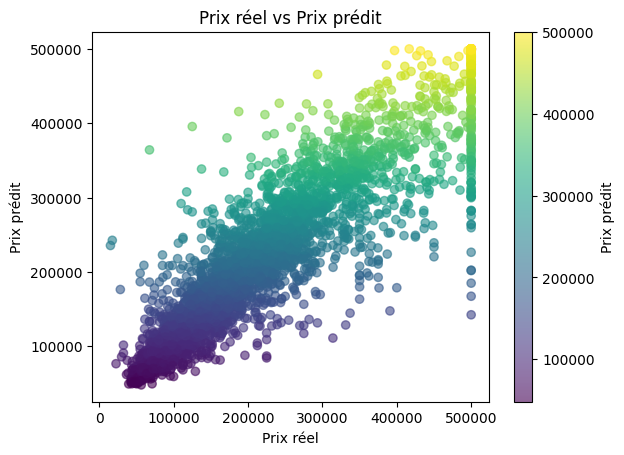

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred, c=y_pred, cmap="viridis", alpha=0.6)
plt.colorbar(label="Prix prédit")
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Prix réel vs Prix prédit")
plt.show()

<Figure size 640x480 with 0 Axes>

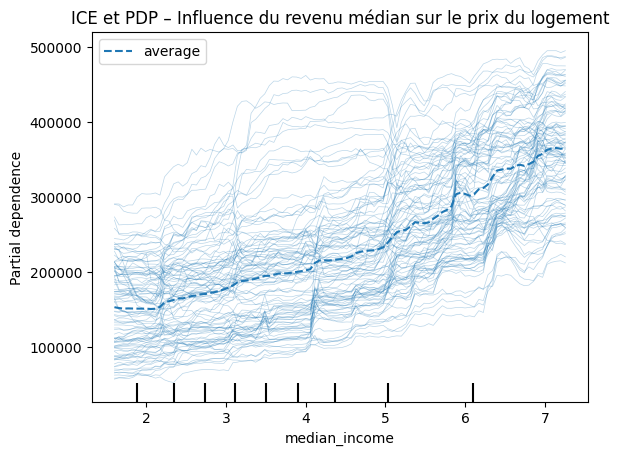

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

plt.figure()

PartialDependenceDisplay.from_estimator(
    estimator=pipeline,
    X=X_test,
    features=["median_income"],
    kind="both",         # ICE + PDP
    subsample=100,
    random_state=42
)

plt.title("ICE et PDP – Influence du revenu médian sur le prix du logement")
plt.show()

<Figure size 640x480 with 0 Axes>

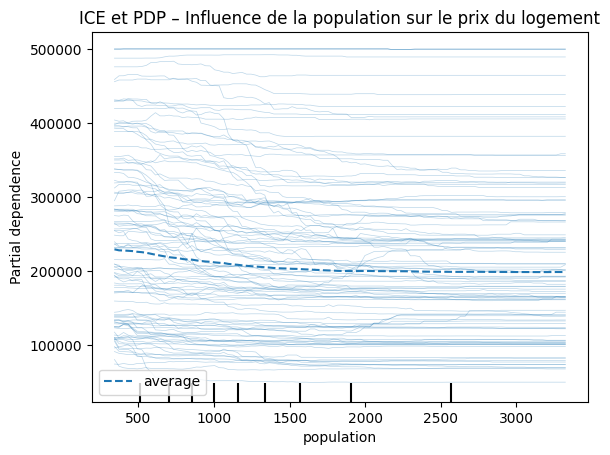

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

plt.figure()

PartialDependenceDisplay.from_estimator(
    estimator=pipeline,
    X=X_test,
    features=["population"],
    kind="both",         # ICE + PDP
    subsample=100,
    random_state=42
)

plt.title("ICE et PDP – Influence de la population sur le prix du logement")
plt.show()